In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [7]:

df = pd.read_csv(r"C:\Users\vivek\PRACTICE PYTHON\PROJECTS\MALL SEGMENTATION\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
df = df.drop("CustomerID",axis=1)

In [12]:
df['Gender']= df['Gender'].map({"Male":0,"Female":1})

In [16]:
X = df.select_dtypes(include=['int64','float64']).values

In [19]:
scaler = StandardScaler()
X_scaled= scaler.fit_transform(X)

C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

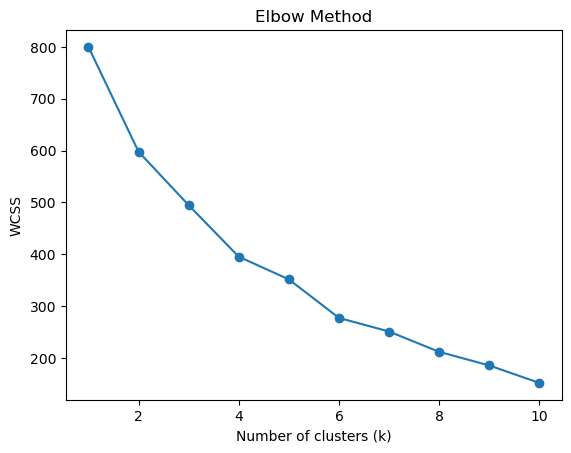

In [26]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init="k-means++",random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

For n_clusters = 2, Silhouette Score = 0.2776
For n_clusters = 3, Silhouette Score = 0.2576
For n_clusters = 4, Silhouette Score = 0.2901
For n_clusters = 5, Silhouette Score = 0.2719
For n_clusters = 6, Silhouette Score = 0.3348


C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

For n_clusters = 7, Silhouette Score = 0.3457
For n_clusters = 8, Silhouette Score = 0.3728
For n_clusters = 9, Silhouette Score = 0.3876
For n_clusters = 10, Silhouette Score = 0.4208


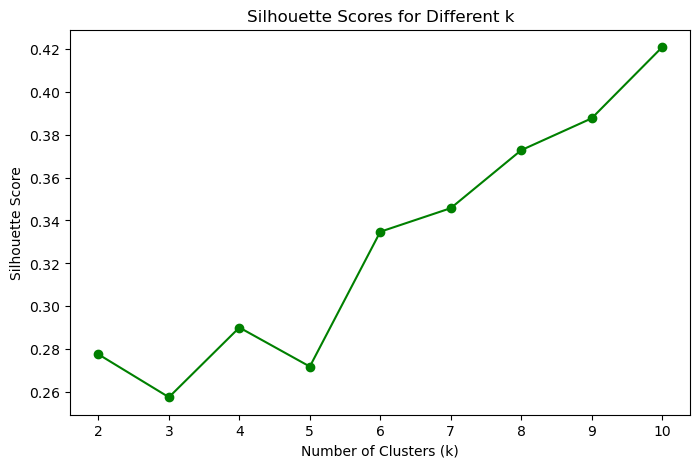

In [27]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Loop from k=2 to 10 (k=1 not allowed for silhouette)
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"For n_clusters = {k}, Silhouette Score = {score:.4f}")

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()


In [28]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)


C:\Users\vivek\anaconda4\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [29]:
df['Cluster'] = y_kmeans

In [30]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.490196  56.470588           46.098039               39.313725
1        0.000000  39.500000           85.150000               14.050000
2        0.000000  28.690476           60.904762               70.238095
3        1.000000  37.897959           82.122449               54.448980
4        1.000000  27.315789           38.842105               56.210526


In [38]:
cluster_labels = {
    0: "Older Low Spenders",
    1: "High-Income Cautious Males",
    2: "Young Big Spenders",
    3: "Affluent Female Shoppers",
    4: "Young Engaged Female Shoppers"
}

df['Cluster_Label'] = df['Cluster'].map(cluster_labels)
print(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster_Label']].head())


   Age  Annual Income (k$)  Spending Score (1-100)  \
0   19                  15                      39   
1   21                  15                      81   
2   20                  16                       6   
3   23                  16                      77   
4   31                  17                      40   

                   Cluster_Label  
0             Young Big Spenders  
1             Young Big Spenders  
2  Young Engaged Female Shoppers  
3  Young Engaged Female Shoppers  
4  Young Engaged Female Shoppers  


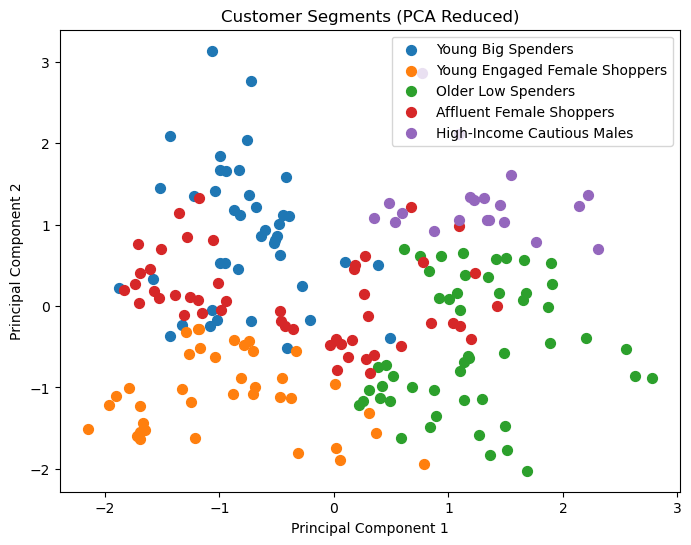

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for label in df['Cluster_Label'].unique():
    idx = df['Cluster_Label'] == label
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=label, s=50)

plt.title('Customer Segments (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


In [40]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_kmeans)
print(score)
print(kmeans.inertia_)


0.27191023466188324
351.74320617119105


In [41]:
df['Cluster_Label'].value_counts()


Cluster_Label
Older Low Spenders               51
Affluent Female Shoppers         49
Young Big Spenders               42
Young Engaged Female Shoppers    38
High-Income Cautious Males       20
Name: count, dtype: int64